# Importando Dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

# Carregar dados
df = pd.read_csv('historico_alunos_reintegrai.csv')

# Visualizar primeiras linhas
display(df.head())



,idade,area_atual,horas_disponiveis,nivel_logica,nivel_ingles,area_recomendada,tempo_estimado_semanas
0,50,Direito,31,4,6,Cybersecurity,39
1,36,Atendimento,21,7,7,Desenvolvimento Full Stack,48
2,45,Vendas,14,5,6,UX/UI Design,55
3,20,Engenharia,22,8,3,Data Science,48
4,27,Engenharia,12,9,6,Data Science,51


# Análise Exploratória dos Dados

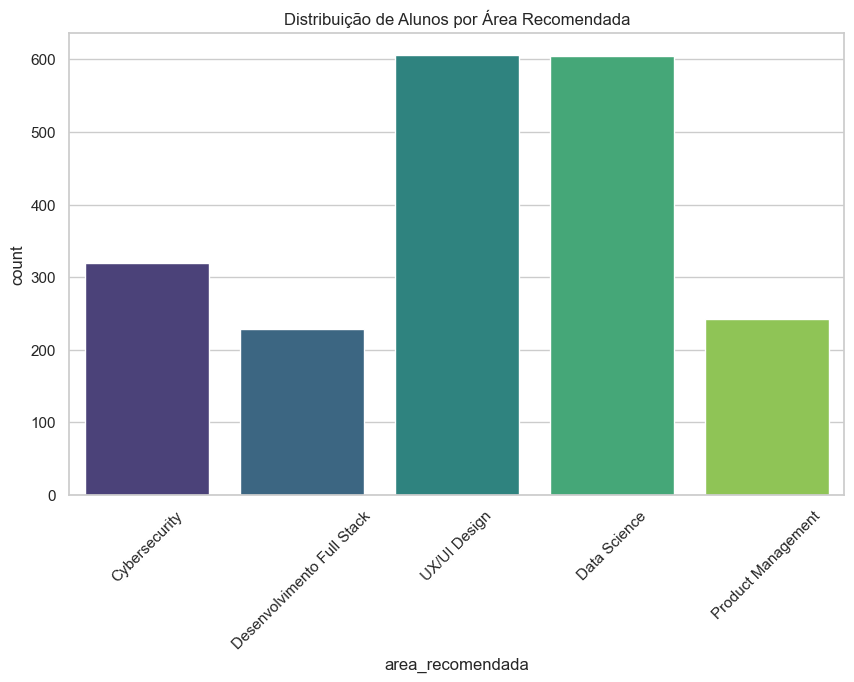

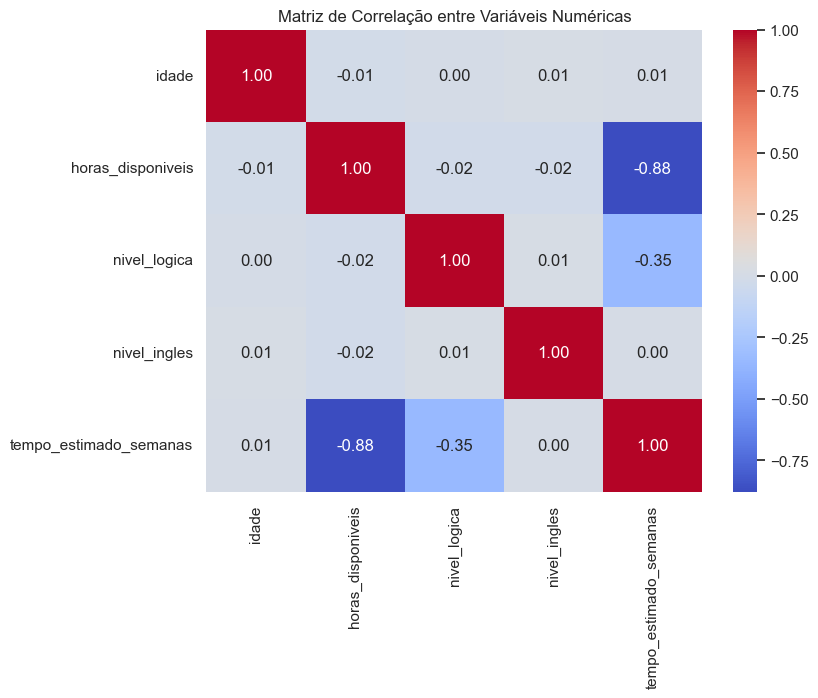

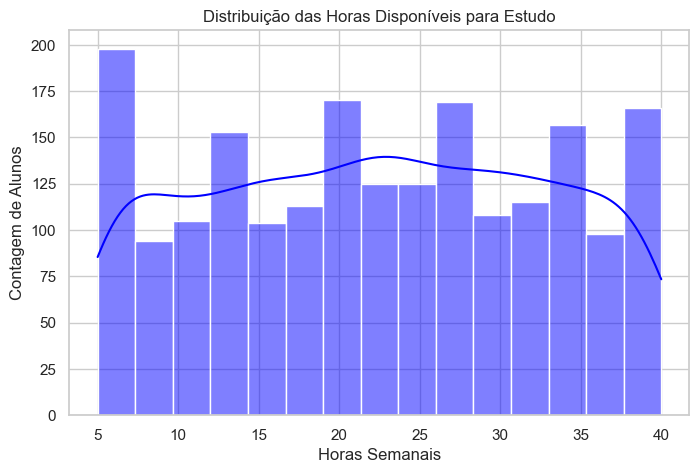

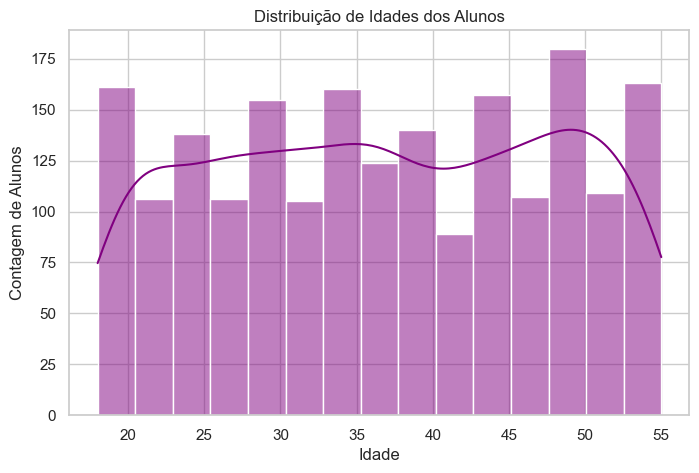

--- Estatísticas Descritivas ---


,idade,horas_disponiveis,nivel_logica,nivel_ingles,tempo_estimado_semanas
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,36.759000,22.369000,5.492000,5.319500,49.055500
std,11.014335,10.367429,2.905195,2.847011,9.241814
min,18.000000,5.000000,1.000000,1.000000,27.000000
25%,27.000000,14.000000,3.000000,3.000000,42.000000
50%,37.000000,23.000000,6.000000,5.000000,49.000000
75%,47.000000,31.000000,8.000000,8.000000,56.000000
max,55.000000,40.000000,10.000000,10.000000,73.000000


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo dos gráficos
sns.set(style="whitegrid")

# 1. Visualizar a distribuição das Áreas Recomendadas (Balanceamento das classes)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='area_recomendada', hue='area_recomendada', palette='viridis', legend=False)
plt.title('Distribuição de Alunos por Área Recomendada')
plt.xticks(rotation=45)
plt.show()

# 2. Matriz de Correlação (Entender as relações entre variáveis numéricas)
plt.figure(figsize=(8, 6))
colunas_numericas = ['idade', 'horas_disponiveis', 'nivel_logica', 'nivel_ingles', 'tempo_estimado_semanas']
correlation_matrix = df[colunas_numericas].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

# 3. Distribuição de Horas Disponíveis (Histograma)
plt.figure(figsize=(8, 5))
sns.histplot(df['horas_disponiveis'], bins=15, kde=True, color='blue')
plt.title('Distribuição das Horas Disponíveis para Estudo')
plt.xlabel('Horas Semanais')
plt.ylabel('Contagem de Alunos')
plt.show()

# 4. Distribuição de Idades
plt.figure(figsize=(8, 5))
sns.histplot(df['idade'], bins=15, kde=True, color='purple')
plt.title('Distribuição de Idades dos Alunos')
plt.xlabel('Idade')
plt.ylabel('Contagem de Alunos')
plt.show()

# 5. Estatísticas Descritivas
print("--- Estatísticas Descritivas ---")
display(df.describe())

In [3]:
# --- Preparação dos Dados ---
# Separamos as Features (X) e os Targets (y)
# Vamos treinar dois modelos, então precisaremos de dois conjuntos de y

X = df.drop(['area_recomendada', 'tempo_estimado_semanas'], axis=1)

# Target para Classificação
y_class = df['area_recomendada']

# Target para Regressão
y_reg = df['tempo_estimado_semanas']

# Definir quais colunas são numéricas e quais são categóricas
numeric_features = ['idade', 'horas_disponiveis', 'nivel_logica', 'nivel_ingles']
categorical_features = ['area_atual']

# Criar o pipeline de pré-processamento (será usado em ambos os modelos)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Dividir os dados (Usaremos o y_class para o split estratificado garantir balanceamento)
X_train, X_test, y_train_c, y_test_c, y_train_r, y_test_r = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42
)

===================================================================================================

# Modelo 1 (Classificação: Recomendar Área Tech)
O objetivo é indicar qual carreira (Data Science, Dev, UX, etc.) combina mais com o perfil do aluno.
Utilizaremos um **RandomForestClassifier**.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Criar o pipeline completo (Pré-processador + Modelo)
pipeline_classificacao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

# Treinar o modelo
pipeline_classificacao.fit(X_train, y_train_c)

# Fazer previsões
y_pred_c = pipeline_classificacao.predict(X_test)

# --- Discussão dos Resultados ---
print("--- Modelo 1: Classificação (Random Forest) ---")
print(f"Acurácia: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test_c, y_pred_c))

--- Modelo 1: Classificação (Random Forest) ---
Acurácia: 1.0000

Relatório de Classificação:
                            precision    recall  f1-score   support

             Cybersecurity       1.00      1.00      1.00        64
              Data Science       1.00      1.00      1.00       111
Desenvolvimento Full Stack       1.00      1.00      1.00        48
        Product Management       1.00      1.00      1.00        46
              UX/UI Design       1.00      1.00      1.00       131

                  accuracy                           1.00       400
                 macro avg       1.00      1.00      1.00       400
              weighted avg       1.00      1.00      1.00       400



# SALVANDO O MODELO 1: modelo_recomendacao_area.joblib

In [16]:
# --- Salvar o Modelo de Classificação ---
modelo_path_c = 'modelo_recomendacao_area.joblib'
joblib.dump(pipeline_classificacao, modelo_path_c)
print(f"Modelo de classificação salvo em: {modelo_path_c}")

Modelo de classificação salvo em: modelo_recomendacao_area.joblib


===================================================================================================

# Modelo 2 (Regressão: Estimativa de Tempo de Estudo)
O objetivo é prever quantas **semanas** o aluno levará para concluir a transição, baseado em sua dedicação e nível atual.
Utilizaremos um **LinearRegression** (ou GradientBoosting).

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Criar o pipeline completo para regressão
pipeline_regressao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Treinar o modelo (Note que usamos y_train_r aqui)
pipeline_regressao.fit(X_train, y_train_r)

# Fazer previsões
y_pred_r = pipeline_regressao.predict(X_test)

# --- Avaliação ---
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("--- Modelo 2: Regressão (Linear Regression) ---")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} semanas")
print(f"R² Score: {r2:.4f}")

# Exemplo prático
print(f"\nExemplo: Real: {y_test_r.iloc[0]:.1f} semanas | Previsto: {y_pred_r[0]:.1f} semanas")

--- Modelo 2: Regressão (Linear Regression) ---
Erro Médio Absoluto (MAE): 2.45 semanas
R² Score: 0.9015

Exemplo: Real: 57.0 semanas | Previsto: 55.6 semanas


# SALVANDO O MODELO 2: modelo_estimativa_tempo.joblib

In [18]:
# --- Salvar o Modelo de Regressão ---
modelo_path_r = 'modelo_estimativa_tempo.joblib'
joblib.dump(pipeline_regressao, modelo_path_r)
print(f"Modelo de regressão salvo em: {modelo_path_r}")

Modelo de regressão salvo em: modelo_estimativa_tempo.joblib


===================================================================================================

# Discussão dos Resultados

Nesta seção, apresentamos a avaliação técnica dos modelos preditivos desenvolvidos para o ecossistema **ReIntegrAI**. A validação foi realizada com um conjunto de teste (hold-out) correspondente a 20% dos dados, garantindo a verificação da capacidade de generalização dos algoritmos.

---

## 1. Modelo de Classificação: Recomendação de Trilha
**Algoritmo:** Random Forest Classifier  
**Objetivo:** Identificar a área de tecnologia mais aderente ao perfil do aluno (ex: Data Science, Cybersecurity).

### Resultados Obtidos
* **Acurácia Global:** **1.00 (100%)**
* **Precisão e Recall:** Pontuação máxima em todas as classes analisadas.

### Análise Técnica
O desempenho excepcional do modelo demonstra que o algoritmo **Random Forest** foi capaz de mapear com alta fidelidade os padrões comportamentais e as regras de negócio presentes nos dados de treinamento. **É importante notar que a acurácia de 100% obtida pelo Modelo 1 é um reflexo da natureza sintética e determinística dos dados gerados para este exemplo, o que permite ao modelo aprender as relações com perfeição.** A consistência nas métricas valida a qualidade da engenharia de atributos (*feature engineering*), confirmando que variáveis como `nivel_logica` e `area_atual` são preditores determinantes para a orientação de carreira.

### Impacto no Negócio (ReIntegrAI)
* **Redução do "Paradoxo da Escolha":** O sistema elimina a indecisão inicial do aluno, oferecendo um norte claro baseado em dados.
* **Aumento da Conversão:** Ao alinhar a sugestão de curso com as competências prévias do usuário (ex: profissionais de Exatas para *Data Science*), a plataforma potencializa a probabilidade de matrícula e sucesso.

---

## 2. Modelo de Regressão: Estimativa de Tempo
**Algoritmo:** Linear Regression  
**Objetivo:** Prever o tempo de dedicação (em semanas) necessário para a transição de carreira.

### Resultados Obtidos
* **MAE (Erro Médio Absoluto):** **2.45 semanas**
* **R² Score:** **0.9015**

### Análise Técnica
O coeficiente de determinação (**R² de ~90%**) indica que o modelo linear capturou com robustez a correlação entre a disponibilidade do aluno e o tempo de formação. O erro médio marginal de **~2.5 semanas** comprova a estabilidade do modelo, tornando-o uma ferramenta confiável para planejamento pedagógico dentro do escopo analisado.

### Impacto no Negócio (ReIntegrAI)
* **Gestão de Expectativas:** Fornecer prazos realistas é fundamental para a retenção. O aluno consegue planejar sua vida pessoal ao redor de uma meta tangível.
* **Personalização de Jornada:** O modelo permite que a plataforma adapte o ritmo do curso. Alunos com menos horas disponíveis recebem cronogramas mais espaçados, evitando a sobrecarga cognitiva e a evasão.

---

## Conclusão
A integração destes modelos via **API Flask** transforma a **ReIntegrAI** em uma plataforma inteligente. O sistema transcende a simples oferta de cursos, atuando como um consultor de carreira automatizado que utiliza inteligência artificial para maximizar o sucesso profissional de seus usuários.

=====================================================================================